# Machine Learning Workflow


Imports:

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


### **Step 1**: Problem Framing

**Problem overview**: 

This dataset contains information on credit card clients in Taiwan. The objective is to predict whether a client will default on their credit card payment in the following month.

The prediction task is a binary classification problem, where our target variable is  default payment in the next month, with values, 1 if Default and 0 if No default.



**Dataset Description**:

Documentation of Data from source ()

The dataset documentation was obtained from the original source, the UCI Machine Learning Repository.

| Study Variable | Dataset Column Name | Description |
|---------------|--------------------|------------|
| ID | ID | Unique client identifier. |
| Response Variable | default payment next month | This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. |
| X1 | LIMIT_BAL | Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit. |
| X2 | SEX | Gender (1 = male; 2 = female). |
| X3 | EDUCATION | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| X4 | MARRIAGE | Marital status (1 = married; 2 = single; 3 = others). |
| X5 | AGE | Age (year). |
| X6 | PAY_0 | History of past payment. The repayment status in September, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above. |
| X7 | PAY_2 | History of past payment. The repayment status in August, 2005. |
| X8 | PAY_3 | History of past payment. The repayment status in July, 2005. |
| X9 | PAY_4 | History of past payment. The repayment status in June, 2005. |
| X10 | PAY_5 | History of past payment. The repayment status in May, 2005. |
| X11 | PAY_6 | History of past payment. The repayment status in April, 2005. |
| X12 | BILL_AMT1 | Amount of bill statement (NT dollar). Amount of bill statement in September, 2005. |
| X13 | BILL_AMT2 | Amount of bill statement in August, 2005. |
| X14 | BILL_AMT3 | Amount of bill statement in July, 2005. |
| X15 | BILL_AMT4 | Amount of bill statement in June, 2005. |
| X16 | BILL_AMT5 | Amount of bill statement in May, 2005. |
| X17 | BILL_AMT6 | Amount of bill statement in April, 2005. |
| X18 | PAY_AMT1 | Amount of previous payment (NT dollar). Amount paid in September, 2005. |
| X19 | PAY_AMT2 | Amount paid in August, 2005. |
| X20 | PAY_AMT3 | Amount paid in July, 2005. |
| X21 | PAY_AMT4 | Amount paid in June, 2005. |
| X22 | PAY_AMT5 | Amount paid in May, 2005. |
| X23 | PAY_AMT6 | Amount paid in April, 2005. |

Source: UCI Machine Learning Repository Default of Credit Card Clients Dataset  
https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

**Modelling Objective**: 

The goal is to build models that estimate the probability of default, not just classify clients.
Evaluation will focus on discrimination (ROC-AUC, PR-AUC) and calibration.


### **Step 2**: Loading the dataset

In [32]:
# Load dataset from the data folder
# header=1 is used because the first row contains X1, X2, ..., Y
# and the second row contains the actual column names
df = pd.read_csv("../data/default_of_credit_card_clients.csv", header=1)

# Display first 5 rows to confirm correct loading
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# Check column names to ensure they match documentation
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [4]:
# Create a preserved copy of the original dataset
# This ensures we never modify the raw data accidentally
df_raw = df.copy()

In [5]:
# Confirm no missing values in the raw dataset
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nTotal missing values: {df_raw.isnull().sum().sum()}")

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

Total missing values: 0


No missing values are present across any of the 25 columns (0 total), confirming the dataset documentation claim. No imputation is required.

### **Step 3**: Defining Target Variable and Distribution 

In [6]:
# Define target variable 
target = "default payment next month"

# Separate features and target from raw dataset 
X_raw = df_raw.drop(columns=[target])
y = df_raw[target]

# Confirm shapes
print("Feature shape:", X_raw.shape)
print("Target shape:", y.shape)

Feature shape: (30000, 24)
Target shape: (30000,)


The dataset contains 30,000 observations and 24 predictor variables (including the ID column at this stage).
The target variable has been successfully separated and is stored as a one-dimensional vector of length 30,000, which is appropriate for binary classification tasks.

The dataset structure is consistent with the documentation and ready for analysis of the target distribution.

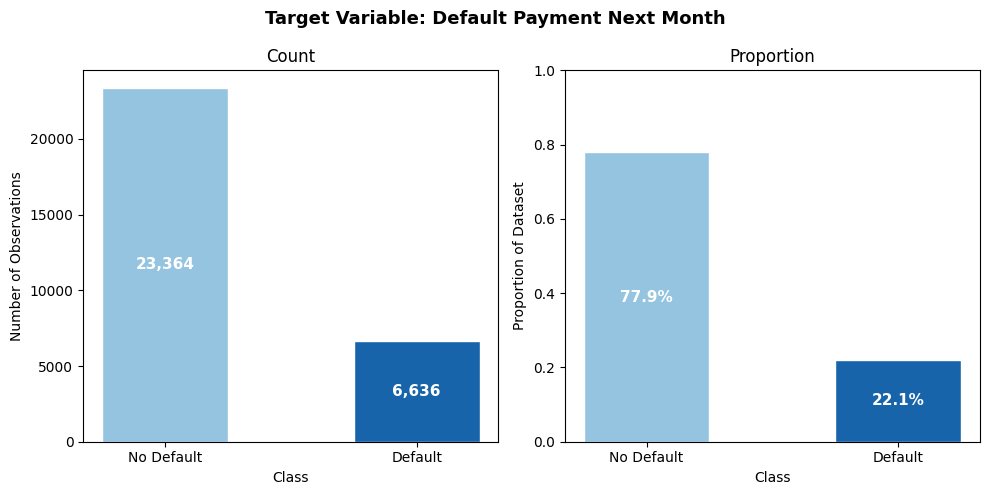

In [7]:
# Examine class distribution - visual
labels = {0: "No Default", 1: "Default"}
counts = y.value_counts().sort_index()
proportions = y.value_counts(normalize=True).sort_index()
class_labels = [labels[i] for i in counts.index]

blues = sns.color_palette("Blues", 4)
colors = [blues[1], blues[3]]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: Count
bars0 = axes[0].bar(class_labels, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Count")
axes[0].set_ylabel("Number of Observations")
axes[0].set_xlabel("Class")
for bar, val in zip(bars0, counts.values):
    y_pos = bar.get_height() / 2
    axes[0].text(bar.get_x() + bar.get_width() / 2, y_pos,
                 f"{val:,}", ha="center", va="center", color="white", fontsize=11, fontweight="bold")

# Right: Proportion
bars1 = axes[1].bar(class_labels, proportions.values, color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Proportion")
axes[1].set_ylabel("Proportion of Dataset")
axes[1].set_xlabel("Class")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars1, proportions.values):
    y_pos = bar.get_height() / 2
    axes[1].text(bar.get_x() + bar.get_width() / 2, y_pos,
                 f"{val:.1%}", ha="center", va="center", color="white", fontsize=11, fontweight="bold")

plt.suptitle("Target Variable: Default Payment Next Month", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

- The dataset exhibits moderate class imbalance, with approximately 78% non default cases and 22% default cases. 

- This means that accuracy alone would be a misleading evaluation metric (a model predicting only “no default” would already achieve high accuracy). 

- To ensure a fair evaluation, stratified splitting should be used to preserve class proportions across training and test sets. (Keep the same percentage of each class in train and test sets as in the full dataset.)

- Model performance will therefore be assessed using discrimination metrics such as ROC-AUC and PR-AUC, alongside calibration analysis to evaluate the quality of predicted probabilities. 

- If the minority (default) class is poorly detected, approaches such as class weighting or threshold adjustment may be considered.

### **Step 4**: Stratified Test/Train Split

In [8]:
# Split the data into training and test sets (before any preprocessing)
# Stratify ensures the class proportions (default vs non-default) remain similar in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Quick checks to confirm split sizes and that stratification worked
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTarget proportions (train):")
print(y_train.value_counts(normalize=True))

print("\nTarget proportions (test):")
print(y_test.value_counts(normalize=True))

X_train shape: (24000, 24)
X_test shape: (6000, 24)

Target proportions (train):
default payment next month
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Target proportions (test):
default payment next month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


Train/Test splitting was performed before any preprocessing to avoid data leakage. 

Stratification successfully preserved the original class proportions (approximately 78% non-default and 22% default) in both the training and test sets, ensuring fair and representative model evaluation.

Leakage risk note: The PAY_* variables show payment behaviour from the months before the target. A real lender would have access to this information before needing to predict whether someone will default. So including these variables is legitimate, we are not accidentally giving the model information it wouldn't have in practice.

### **4.1 Target distribution (y_train and y_test):**

We examine the target distribution to quantify class imbalance and confirm that the train–test split preserved default proportions, since this affects evaluation metrics and modelling choices.

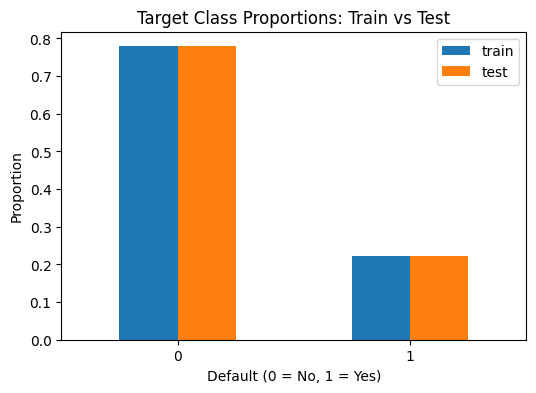

In [9]:


# Plot: target proportions train vs test

target_props = (
    (y_train.value_counts(normalize=True).sort_index().rename("train"))
    .to_frame()
    .join(y_test.value_counts(normalize=True).sort_index().rename("test"))
)

target_props.plot(kind="bar", figsize=(6,4))
plt.title("Target Class Proportions: Train vs Test")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

**Interpretation of Target Class**:

The training set contains 18,691 non-default observations (77.9%) and 5,309 default observations (22.1%), indicating a moderate class imbalance. The test set exhibits nearly identical proportions (77.9% non-default, 22.1% default), confirming that the train–test split preserved the class distribution.

The close alignment between training and test proportions suggests that the split was performed appropriately and that model evaluation will not be biased by distributional shifts between datasets.

From a modelling perspective, the imbalance is not extreme but is meaningful. Accuracy alone would be insufficient as an evaluation metric, since a naive classifier predicting only non-default would achieve approximately 78% accuracy. Therefore, performance metrics such as ROC-AUC, precision–recall, F1-score, and recall for the minority class will be more informative in assessing predictive performance.

The baseline default rate of approximately 22% also provides a useful reference point when interpreting model outputs and feature effects.

### **Step 5**: Remove Non-Predictive Identifier (ID Column)

In [10]:
# Remove ID column from training and test feature sets as it is not a predictive feature
X_train = X_train.drop(columns=["ID"])
X_test = X_test.drop(columns=["ID"])

print("X_train shape after dropping ID:", X_train.shape)
print("X_test shape after dropping ID:", X_test.shape)

X_train shape after dropping ID: (24000, 23)
X_test shape after dropping ID: (6000, 23)


The ID column has been successfully removed from both the training and test feature sets. The feature matrices now contain 23 predictor variables.

ID is a unique identifier and does not contain predictive information. It is removed prior to modelling and interpretation to ensure that the model is trained only on meaningful explanatory variables and that subsequent feature importance or coefficient analysis reflects substantive predictors rather than arbitrary identifiers.

### **Step 6**: Feature Type Identification and Preprocessing Design

**Note**: Although the dataset documentation provides the intended meaning of each variable, it is important to verify that the observed data matches this description. Documentation specifies what variables are supposed to represent, while exploratory data analysis confirms how they actually behave in the dataset. This verification step ensures consistency, detects unexpected codes, and strengthens modelling validity.

#### **6.1: Checking datatypes**:

To understand how variables are stored in the dataset and to verify whether numeric looking variables may actually represent encoded categorical or ordinal features.

In [11]:
X_train.dtypes

LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
dtype: object

Most variables are stored as integers. However, storage type alone does not determine modelling treatment. Integer encoding may represent true numeric quantities (e.g. monetary amounts) or simply category codes (e.g. education levels). Therefore, further inspection is required before determining preprocessing strategy.

#### **6.2: Checking Number of Unique Values**:

To use the number of unique values as an initial heuristic for distinguishing between binary, categorical, ordinal, and continuous variables. This does not determine structure definitively but provides guidance when interpreted alongside documentation.

In [12]:
# Count number of unique values in each feature
unique_counts = X_train.nunique().sort_values()
unique_counts

SEX              2
MARRIAGE         4
EDUCATION        7
PAY_5           10
PAY_6           10
PAY_2           11
PAY_3           11
PAY_0           11
PAY_4           11
AGE             55
LIMIT_BAL       80
PAY_AMT5      5985
PAY_AMT6      6014
PAY_AMT4      6075
PAY_AMT3      6558
PAY_AMT2      6882
PAY_AMT1      6924
BILL_AMT6    16970
BILL_AMT5    17304
BILL_AMT4    17764
BILL_AMT3    18112
BILL_AMT2    18400
BILL_AMT1    18671
dtype: int64

- Sex contains two discrete values (1, 2), consistent with documentation indicating binary gender categories. These values are therefore treated as a binary categorical feature.
- Education and Marriage contain a small number of discrete coded levels. According to the dataset documentation, these codes represent category labels (e.g. graduate school, university, and married, single). Whether these should be treated as nominal or ordinal requires further investigation during EDA. The encoding strategy will be determined after examining the relationship between these variables and the target.
- The repayment status variables (PAY_0–PAY_6) show a limited number of discrete levels. Documentation indicates these values represent increasing levels of payment delay, suggesting an ordered structure that we will further verify through visual analysis.
- Financial variables such as LIMIT_BAL, BILL_AMT*, and PAY_AMT* measure monetary amounts (NT dollars). Because differences between values represent real quantitative changes, they are treated as continuous features.

#### **6.3: Inspecting Unique Values of Suspected Categorical / Ordinal Features**:

To verify that observed category codes align with documentation and to confirm whether repayment status variables demonstrate an ordered structure.

In [13]:
# Columns that are typically categorical/ordinal in this dataset
suspected_cat_ord = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Show unique values for each (sorted) to confirm encoding and ranges
for col in suspected_cat_ord:
    print(f"{col}: {sorted(X_train[col].unique())[:20]}{' ...' if X_train[col].nunique() > 20 else ''}")

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: [np.int64(-2), np.int64(-1), np.int64(0), n

Sex contains values consistent with documentation. Education and Marriage contain additional codes (0, 5, 6 for Education; 0 for Marriage) not described in the original documentation. These will be examined further during visual analysis.

The PAY_* variables contain discrete integer levels (e.g., −1, 0, 1, …, 9). According to the dataset documentation, these values represent increasing levels of repayment delay. This documented progression implies a meaningful order. Therefore, these variables are treated as ordinal features, where the ranking of levels matters even if the spacing between levels may not be strictly linear.



#### **6.3: Descriptive Statistics for Numeric Amount Variables**: 

To confirm that financial variables behave as measurable numeric quantities and to inspect scale differences or potential extreme values.

In [14]:
# Amount-type columns to sanity check ranges
amount_cols = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)] + ["AGE"]

X_train[amount_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,24000.0,167364.666667,129511.313151,10000.0,50000.00,140000.0,240000.00,1000000.0
BILL_AMT1,24000.0,51100.502250,73510.032060,-165580.0,3513.75,22330.0,66966.50,964511.0
BILL_AMT2,24000.0,49012.267583,70840.102410,-69777.0,2989.75,21107.0,63992.75,983931.0
BILL_AMT3,24000.0,46861.880083,68403.933692,-61506.0,2652.00,20031.0,60033.75,855086.0
BILL_AMT4,24000.0,43156.661458,64046.730878,-81334.0,2332.00,19004.5,54386.50,891586.0
BILL_AMT5,24000.0,40164.412625,60627.850612,-81334.0,1746.00,18102.5,50142.25,927171.0
BILL_AMT6,24000.0,38675.979875,59308.737828,-339603.0,1225.00,16993.0,48977.25,961664.0
PAY_AMT1,24000.0,5623.556292,16148.316646,0.0,1000.00,2100.5,5018.25,873552.0
PAY_AMT2,24000.0,5879.974917,20252.983189,0.0,840.00,2014.0,5000.00,1215471.0
PAY_AMT3,24000.0,5215.777583,17513.554475,0.0,390.00,1805.5,4580.50,896040.0


The summary statistics indicate that LIMIT_BAL, BILL_AMT*, and PAY_AMT* span wide numeric ranges and exhibit substantial variation across observations. This is directly observed from the descriptive statistics output.

According to the dataset documentation, these variables represent monetary amounts (in NT dollars). Because they measure real quantitative values where arithmetic differences are meaningful, they are treated as continuous variables.

The summary statistics show substantial differences in numeric magnitude across continuous variables (e.g., credit limits versus age). Since some machine learning models are sensitive to feature scale, this will be considered during preprocessing

While descriptive statistics provide an initial indication of dispersion and potential extreme values, visual inspection (e.g. boxplots) will be used to assess skewness and outlier behaviour more clearly. At this stage, no outlier removal is performed, as extreme financial values may contain meaningful predictive signal.

Feature classification is determined by combining documentation review with empirical verification through exploratory analysis. While many variables are encoded as integers, they represent conceptually distinct types:

1. Binary categorical (SEX)

2. Nominal/Ordinal categorical (EDUCATION, MARRIAGE, PAY_*)

3. Continuous (LIMIT_BAL, AGE, BILL_AMT*, PAY_AMT*)

Accurate classification ensures that each feature receives appropriate preprocessing treatment within the modelling pipeline. Misclassifying encoded categories as numeric quantities would impose incorrect statistical assumptions and potentially distort model interpretation. This structured approach supports methodological rigour and statistical validity.


### **Step 7**: Exploratory Visual Analysis of Continuous Variables

Before designing the preprocessing pipeline, we conduct visual inspection of continuous variables to assess distribution shape, dispersion, and potential extreme values. While descriptive statistics provide summary measures, they do not fully capture skewness or outlier structure. Boxplots allow visual identification of spread and extreme observations.

### **7.1 Boxplots - Continuous Variables:**

Boxplots  applied only to continuous variables, as categorical and ordinal variables do not have meaningful numeric dispersion in the same way.

Although representative variables could provide a general indication of distributional behaviour, all continuous variables are visualised to ensure that no month specific or feature specific distributional differences are overlooked. Since bill amounts and payment amounts are recorded across multiple months, inspecting each variable individually allows verification of consistency in dispersion, skewness, and extreme values across time.

This comprehensive inspection supports robust preprocessing decisions and avoids assuming homogeneity across related features.

#### **7.1.1 Monetary Behaviour Variables** 

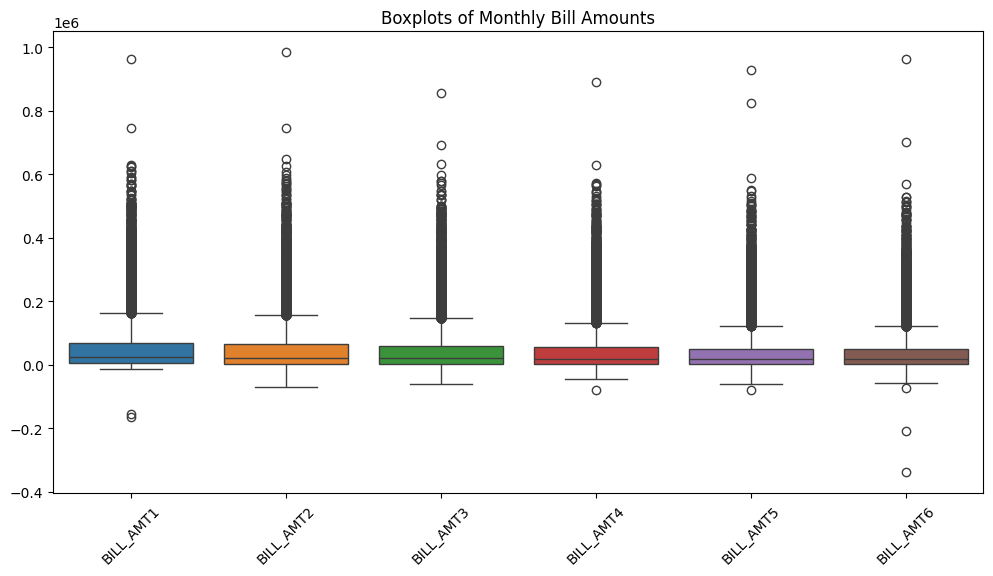

In [15]:
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=X_train[bill_cols])
plt.title("Boxplots of Monthly Bill Amounts")
plt.xticks(rotation=45)
plt.show()

**Interpretation of Monthly Bill Amounts**:

The six monthly bill amount boxplots exhibit broadly similar distributional patterns across time. In each month, the median lies relatively low within the overall range, while the upper whisker extends substantially upward and is followed by a large number of high-value outliers approaching one million. The interquartile ranges appear comparable across all months, suggesting similar dispersion in the central billing values. There is no clear shift in medians or spread across months, indicating that the distribution of bill amounts remains broadly consistent over the six-month period.

A small number of negative balances are also visible across several months. Since these variables represent monthly statement balances, such values plausibly reflect overpayments, refunds, or billing adjustments. Their magnitude is small relative to the positive tail and they do not materially affect the overall distributional pattern.

Overall, the distributions are strongly right-skewed due to the presence of very large billing values. This indicates that while most customers maintain relatively modest balances, a small number carry substantially higher statement amounts.


#### **7.1.2 Payment Variables** 

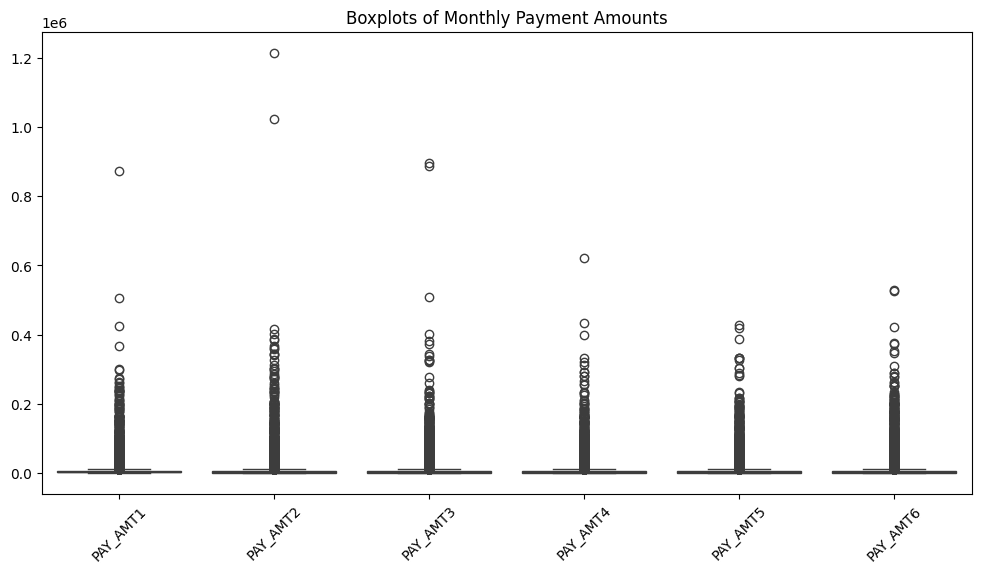

In [16]:

pay_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=X_train[pay_cols])
plt.title("Boxplots of Monthly Payment Amounts")
plt.xticks(rotation=45)
plt.show()

**Interpretation of Monthly Payment Amounts Original**: 

On the original scale, the payment distributions are dominated by a pronounced upper tail, with values extending far beyond the central mass of the data and compressing the interquartile ranges near zero. The boxes appear flattened against the lower end of the axis, making median and IQR comparisons across months visually indistinguishable. Under the IQR rule, many observations are plotted beyond the upper whisker; however, given the financial context, these likely represent legitimately large payments rather than data errors. The visual compression indicates that the majority of customers make relatively modest payments compared to a small subset of exceptionally large transactions. 

Because these extreme values stretch the scale, meaningful comparison of central tendency and dispersion across months is not possible on the raw axis.

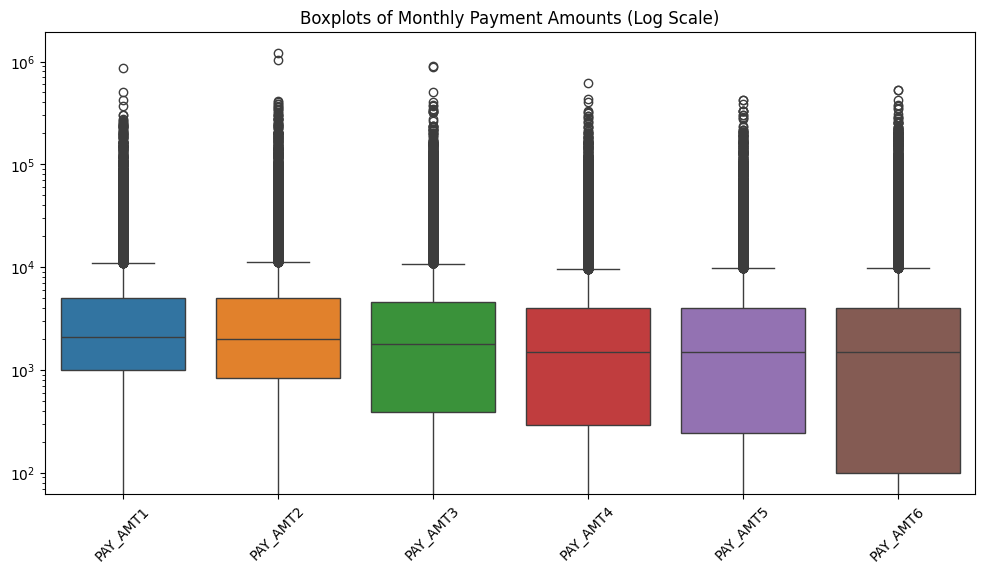

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train[pay_cols])
plt.yscale("log")
plt.title("Boxplots of Monthly Payment Amounts (Log Scale)")
plt.xticks(rotation=45)
plt.show()

**Interpretation of Monthly Payment Amounts Logged**: 

When plotted on a logarithmic scale, the central distribution of payment amounts becomes more clearly observable, resolving the compression seen on the raw axis. The medians are now distinguishable across months, and the interquartile ranges can be meaningfully compared. While right-skewness remains evident in all months, later periods particularly PAY_AMT3, 4, 5 and 6, display moderately wider interquartile ranges, indicating greater dispersion in typical payment values. In contrast, PAY_AMT1 and PAY_AMT2 appear more concentrated around their medians.

The transformation therefore reveals modest differences in variability across months that were completely masked on the original scale. Rather than identical distributions over time, the log-scale plot suggests slightly increasing variability in payment behaviour in later months.

#### **7.1.3 Credit Limit Boxplot** 

C:\Users\polym\AppData\Local\Temp\ipykernel_28004\740269598.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


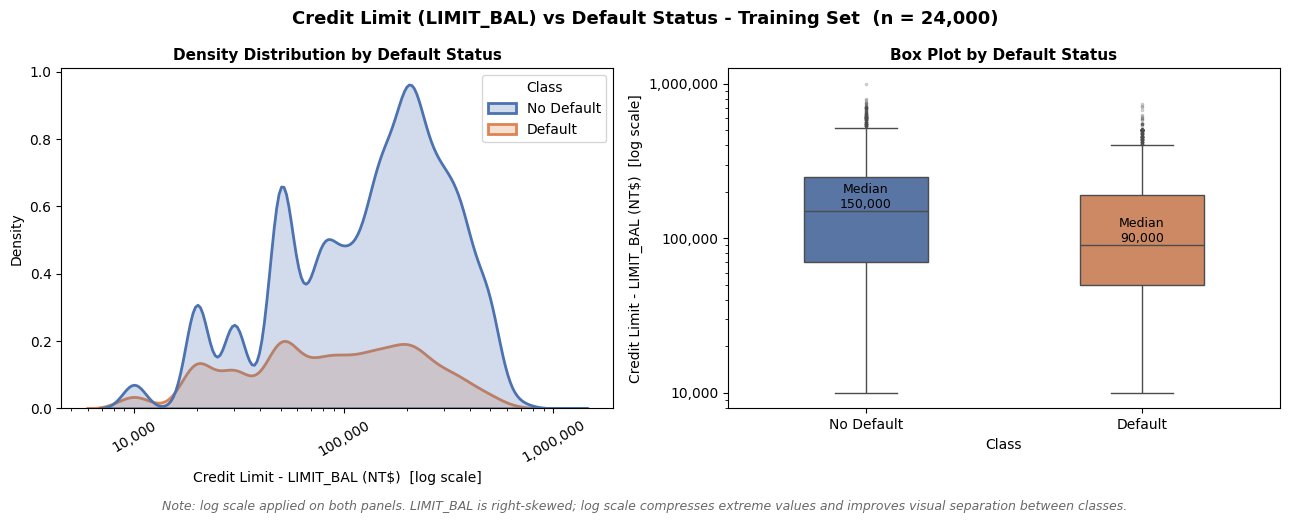

In [18]:
# Credit Limit (LIMIT_BAL) distribution split by default status
# Log scale applied: LIMIT_BAL is right-skewed; log scale spreads the mass and aids class separation

import matplotlib.ticker as mticker

plot_df = pd.DataFrame({
    "LIMIT_BAL": X_train["LIMIT_BAL"].values,
    "Class":     y_train.map({0: "No Default", 1: "Default"}).values
})

palette      = {"No Default": "#4C72B0", "Default": "#DD8452"}
class_order  = ["No Default", "Default"]
fmt_nt       = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overlapping KDE (log scale)
sns.kdeplot(
    data=plot_df, x="LIMIT_BAL", hue="Class", hue_order=class_order,
    palette=palette, fill=True, alpha=0.25, linewidth=2,
    log_scale=True, ax=axes[0]
)
axes[0].set_title("Density Distribution by Default Status", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Credit Limit - LIMIT_BAL (NT$)  [log scale]", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].xaxis.set_major_formatter(fmt_nt)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend_.set_title("Class")

# Right: side-by-side boxplots (log scale)
sns.boxplot(
    data=plot_df, x="Class", y="LIMIT_BAL", order=class_order,
    palette=palette, width=0.45,
    flierprops={"marker": ".", "markersize": 3, "alpha": 0.3},
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Box Plot by Default Status", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Class", fontsize=10)
axes[1].set_ylabel("Credit Limit - LIMIT_BAL (NT$)  [log scale]", fontsize=10)
axes[1].yaxis.set_major_formatter(fmt_nt)

for i, cls in enumerate(class_order):
    med = plot_df.loc[plot_df["Class"] == cls, "LIMIT_BAL"].median()
    axes[1].text(i, med * 1.0, f"Median\n{int(med):,}",
                 ha="center", va="bottom", fontsize=9, color="black")

fig.suptitle(
    "Credit Limit (LIMIT_BAL) vs Default Status - Training Set  (n = {:,})".format(len(plot_df)),
    fontsize=13, fontweight="bold"
)
fig.text(
    0.5, -0.02,
    "Note: log scale applied on both panels. LIMIT_BAL is right-skewed; "
    "log scale compresses extreme values and improves visual separation between classes.",
    ha="center", fontsize=9, style="italic", color="dimgrey"
)

plt.tight_layout()
plt.show()

**Interpretation of Credit Limit**:

LIMIT_BAL shows a noticeable shift between defaulters and non-defaulters. Non-defaulting clients have a median credit limit of NT$150,000 compared to NT$90,000 for defaulters, a difference of roughly 67%. The KDE indicates that the No Default distribution extends further into higher credit limits, while defaulters are more concentrated at lower limits. This suggests that lower credit limits are associated with a higher likelihood of default in this dataset.

However, the interquartile ranges overlap considerably, indicating that LIMIT_BAL alone does not provide sufficient separation for accurate classification and must be considered alongside other variables. LIMIT_BAL is therefore retained as a useful predictive feature for subsequent modelling.


**7.1.4 Age Boxplot**

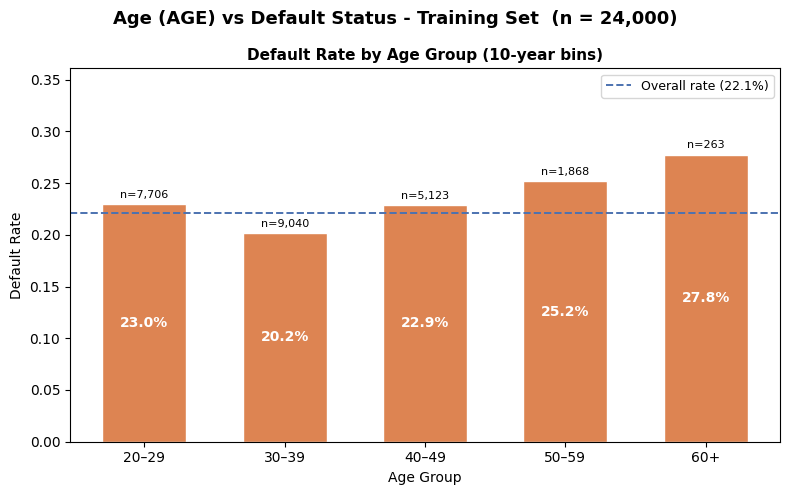

In [19]:
# AGE: raw distribution + default rate by 10-year age group
# Two-panel figure: left = histogram by class, right = default rate per bin

age_df = pd.DataFrame({
    "AGE":     X_train["AGE"].values,
    "Default": y_train.values,
    "Class":   y_train.map({0: "No Default", 1: "Default"}).values
})

# 10-year bins (last bin is open-ended to absorb all ages >= 60)
age_bins   = [20, 30, 40, 50, 60, 100]
age_labels = ["20–29", "30–39", "40–49", "50–59", "60+"]
age_df["Age Group"] = pd.cut(age_df["AGE"], bins=age_bins, labels=age_labels, right=False)

# Default rate + count per bin
bin_stats = (
    age_df.groupby("Age Group", observed=True)["Default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n"})
    .reset_index()
)

palette     = {"No Default": "#4C72B0", "Default": "#DD8452"}
class_order = ["No Default", "Default"]
overall_rate = y_train.mean()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))



# ── Right: default rate bars with n annotations ──────────────────────────────
bars = ax.bar(
    bin_stats["Age Group"].astype(str),
    bin_stats["default_rate"],
    color="#DD8452", edgecolor="white", width=0.6
)

for bar, row in zip(bars, bin_stats.itertuples()):
    h = bar.get_height()
    # rate inside bar
    ax.text(
        bar.get_x() + bar.get_width() / 2, h / 2,
        f"{row.default_rate:.1%}",
        ha="center", va="center", color="white", fontsize=10, fontweight="bold"
    )
    # sample size above bar
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.004,
        f"n={row.n:,}",
        ha="center", va="bottom", color="black", fontsize=8
    )

# Overall default rate reference line
ax.axhline(
    overall_rate, color="#4C72B0", linestyle="--", linewidth=1.4,
    label=f"Overall rate ({overall_rate:.1%})"
)
ax.set_ylim(0, bin_stats["default_rate"].max() * 1.3)
ax.set_title("Default Rate by Age Group (10-year bins)", fontsize=11, fontweight="bold")
ax.set_xlabel("Age Group", fontsize=10)
ax.set_ylabel("Default Rate", fontsize=10)
ax.legend(fontsize=9)

fig.suptitle(
    "Age (AGE) vs Default Status - Training Set  (n = {:,})".format(len(age_df)),
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

**Interpretation of Age**: 

The default rate across age groups does not follow a simple monotonic pattern. The 20–29 group begins slightly above the overall default rate at 23.0%, declines to its lowest point at 30–39 (20.2%, the only group clearly below the overall rate of 22.1%), and then rises through 40–49 (22.9%) and 50–59 (25.2%), reaching its highest observed level at 60+ (27.8%). The pattern therefore resembles a shallow U-shape with a minimum at 30–39 rather than a consistent upward or downward trend.

The 60+ group has the highest observed default rate but contains only 263 observations, meaning this estimate is subject to greater sampling variability than the other bins. The 50–59 group (n=1,868) provides a more stable indication that default rates may increase among older clients relative to middle-aged groups.

Overall, the differences across age groups are moderate, spanning roughly seven percentage points from the lowest to highest rates among well-represented bins. This suggests that age is associated with some variation in default risk, although the effect appears relatively modest when viewed in isolation. AGE is therefore retained as a potentially informative feature, while the extent of its predictive contribution relative to other variables will be evaluated during the modelling stage. Age binning may also be explored as a supplementary feature engineering step if non-linear relationships prove useful for prediction.


### **7.2 BarPlots - Categorical Variables:**

Bar plots and value counts are used for categorical variables because numeric dispersion is not meaningful; instead, we examine frequency distribution and default rate differences across categories.

**7.2.1 Distribution of Sex**

Sex distribution (proportions):
SEX
1    0.39525
2    0.60475
Name: proportion, dtype: float64


C:\Users\polym\AppData\Local\Temp\ipykernel_28004\3457660079.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.countplot(x=sex_mapped, order=sex_order, palette=sex_palette, ax=axes[0])
C:\Users\polym\AppData\Local\Temp\ipykernel_28004\3457660079.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=sex_mapped, y=y_train, order=sex_order, palette=sex_palette, ax=axes[1])


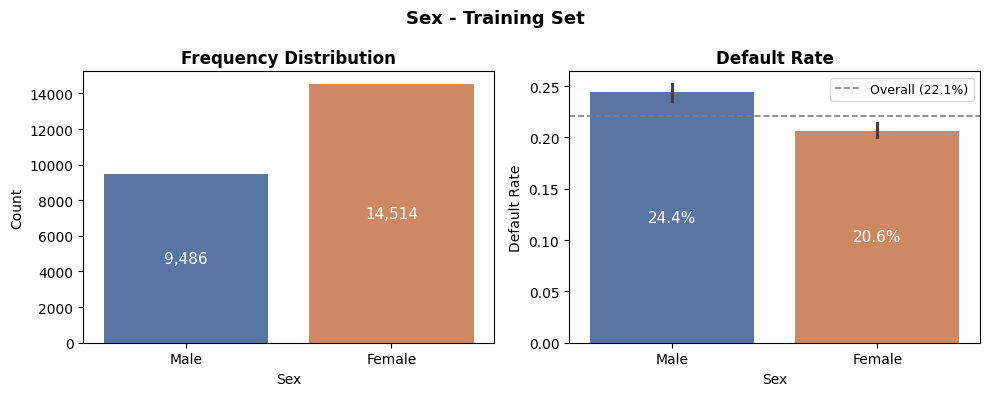

In [20]:
sex_labels  = {1: "Male", 2: "Female"}
sex_palette = ["#4C72B0", "#DD8452"]
sex_mapped  = X_train["SEX"].map(sex_labels)
sex_order   = ["Male", "Female"]

print("Sex distribution (proportions):")
print(X_train["SEX"].value_counts(normalize=True).sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: frequency distribution
ax0 = sns.countplot(x=sex_mapped, order=sex_order, palette=sex_palette, ax=axes[0])
axes[0].set_title("Frequency Distribution", fontweight="bold")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")
for p in ax0.patches:
    h = p.get_height()
    ax0.text(p.get_x() + p.get_width() / 2, h / 2,
             f"{int(h):,}", ha="center", va="center", color="white", fontsize=11)

# Right: default rate
ax1 = sns.barplot(x=sex_mapped, y=y_train, order=sex_order, palette=sex_palette, ax=axes[1])
axes[1].set_title("Default Rate", fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Default Rate")
overall_rate = y_train.mean()
axes[1].axhline(overall_rate, color="grey", linestyle="--", linewidth=1.2,
                label=f"Overall ({overall_rate:.1%})")
axes[1].legend(fontsize=9)
for p in ax1.patches:
    rate = p.get_height()
    if rate > 0:
        ax1.text(p.get_x() + p.get_width() / 2, rate / 2,
                 f"{rate:.1%}", ha="center", va="center", color="white", fontsize=11)

fig.suptitle("Sex - Training Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The training sample consists of 14,514 females (approximately 60.5%) and 9,486 males (approximately 39.5%), indicating moderate imbalance but with both groups well represented.

The observed default rate is 0.206 for females and 0.244 for males, corresponding to a difference of approximately 3.8 percentage points. The confidence intervals displayed on the bar plot do not show overlap, suggesting that the difference in default rates is unlikely to be driven purely by sampling variability.

Overall, sex appears to be associated with default probability in this sample, with males exhibiting a higher observed default rate. The magnitude of the difference is moderate relative to the overall default rate (~22%), indicating that while SEX may contain useful predictive information, it is unlikely to be sufficient for accurate classification on its own and should be considered alongside other variables during modelling

**7.2.2 Distribution of Education**

In [21]:
# Education Distribution

print("Education distribution (proportions):")
print(X_train["EDUCATION"].value_counts(normalize=True).sort_index())

Education distribution (proportions):
EDUCATION
0    0.000500
1    0.352292
2    0.469000
3    0.162625
4    0.004042
5    0.009792
6    0.001750
Name: proportion, dtype: float64


The Education variable contains additional category codes (0, 5, and 6) that are not clearly described in the original documentation. These categories occur at extremely low frequencies, suggesting either residual coding extensions or unspecified classifications. Given their rarity, any statistics derived from these groups are likely to be unstable and should be interpreted with caution.

Unexpected EDUCATION codes: []


C:\Users\polym\AppData\Local\Temp\ipykernel_28004\1931010258.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.countplot(x=edu_mapped, order=order_all, palette="Blues", ax=axes[0])
C:\Users\polym\AppData\Local\Temp\ipykernel_28004\1931010258.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=edu_doc, y=y_doc, order=order_doc, palette="Blues", ax=axes[1])


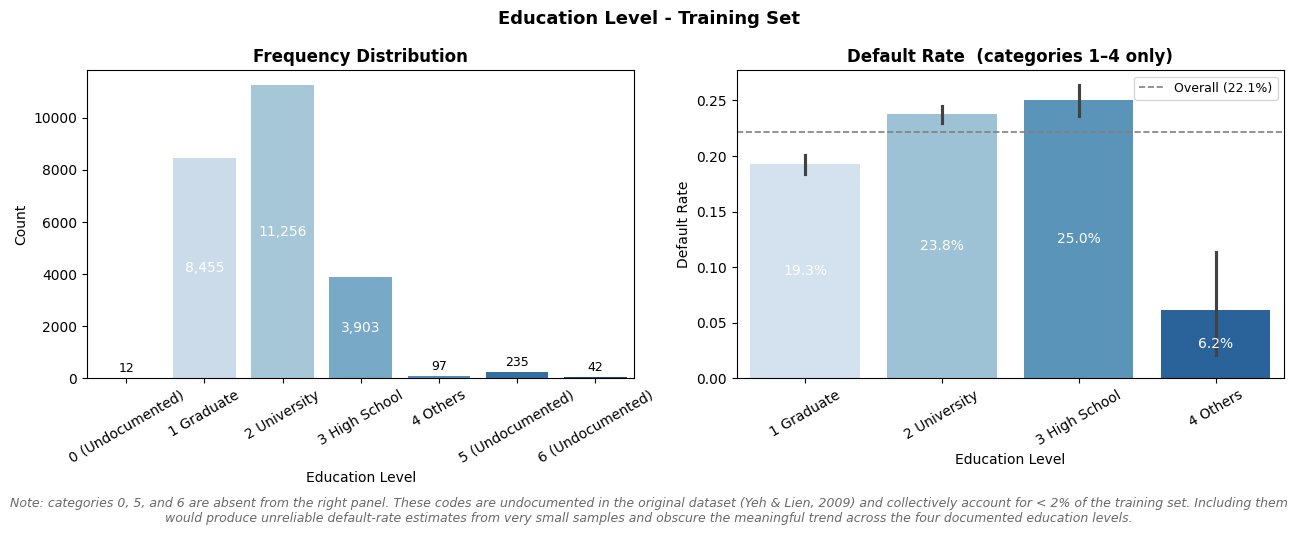

In [22]:
education_labels = {
    0: "0 (Undocumented)",
    1: "1 Graduate",
    2: "2 University",
    3: "3 High School",
    4: "4 Others",
    5: "5 (Undocumented)",
    6: "6 (Undocumented)"
}

unexpected = X_train.loc[~X_train["EDUCATION"].isin(education_labels.keys()), "EDUCATION"].unique()
print("Unexpected EDUCATION codes:", unexpected)

edu_mapped = X_train["EDUCATION"].map(education_labels)
order_all = [education_labels[i] for i in sorted(education_labels.keys())]

# Documented categories only (for default rate panel)
documented = {1: "1 Graduate", 2: "2 University", 3: "3 High School", 4: "4 Others"}
order_doc  = [documented[i] for i in sorted(documented.keys())]
mask_doc   = X_train["EDUCATION"].isin(documented.keys())
edu_doc    = X_train.loc[mask_doc, "EDUCATION"].map(documented)
y_doc      = y_train.loc[mask_doc]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: frequency distribution (all categories)
ax0 = sns.countplot(x=edu_mapped, order=order_all, palette="Blues", ax=axes[0])
axes[0].set_title("Frequency Distribution", fontweight="bold")
axes[0].set_xlabel("Education Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

max_h = max(p.get_height() for p in ax0.patches)
for p in ax0.patches:
    h = p.get_height()
    x = p.get_x() + p.get_width() / 2
    if h < max_h * 0.05:
        ax0.text(x, h + max_h * 0.01, f"{int(h)}",
                 ha="center", va="bottom", color="black", fontsize=9)
    else:
        ax0.text(x, h / 2, f"{int(h):,}",
                 ha="center", va="center", color="white", fontsize=10)

# Right: default rate (documented categories 1-4 only)
ax1 = sns.barplot(x=edu_doc, y=y_doc, order=order_doc, palette="Blues", ax=axes[1])
axes[1].set_title("Default Rate  (categories 1–4 only)", fontweight="bold")
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel("Default Rate")
axes[1].tick_params(axis="x", rotation=30)

overall_rate = y_train.mean()
axes[1].axhline(overall_rate, color="grey", linestyle="--", linewidth=1.2,
                label=f"Overall ({overall_rate:.1%})")
axes[1].legend(fontsize=9)

for p in ax1.patches:
    rate = p.get_height()
    x = p.get_x() + p.get_width() / 2
    if rate < 0.05:
        ax1.text(x, rate + 0.01, f"{rate:.1%}",
                 ha="center", va="bottom", color="black", fontsize=9)
    else:
        ax1.text(x, rate / 2, f"{rate:.1%}",
                 ha="center", va="center", color="white", fontsize=10)

fig.suptitle("Education Level - Training Set", fontsize=13, fontweight="bold")

fig.text(
    0.5, -0.04,
    "Note: categories 0, 5, and 6 are absent from the right panel. "
    "These codes are undocumented in the original dataset (Yeh & Lien, 2009) and collectively account for < 2% of the training set. "
    "Including them would produce unreliable default-rate estimates from very small samples and obscure the meaningful trend across the four documented education levels.",
    ha="center", fontsize=9, style="italic", color="dimgrey",
    wrap=True
)

plt.tight_layout()
plt.show()

The frequency distribution shows that the dataset is dominated by three education groups: University (n = 11,256), Graduate School (n = 8,455), and High School (n = 3,903), which together account for over 98% of the training sample. Categories 0, 5, and 6 are undocumented codes not described in the original dataset documentation and contain very few observations (n = 12, n = 235, n = 42, respectively).

Among the four documented categories, a general pattern is visible. Graduate school clients exhibit the lowest default rate (19.3%), below the overall rate of 22.1%, while High School clients have the highest observed default rate (25.0%). University clients lie between these groups at 23.8%. This pattern suggests that default rates tend to be somewhat higher among clients with lower recorded education levels, although the differences are moderate.

Category 4 (Others) shows a default rate of 6.2%, but this estimate should be interpreted cautiously because the group contains only 97 observations, resulting in a wide confidence interval and substantial sampling uncertainty.

Overall, the plot indicates that education level is associated with some variation in default rates across groups. However, the differences between the major categories are relatively modest, suggesting that EDUCATION alone is unlikely to strongly separate defaulters from non-defaulters and should be interpreted alongside other variables during modelling.

Undocumented education codes (0, 5, 6) are extremely rare in the dataset. Because such small groups can produce unstable default-rate estimates, they are excluded from the default-rate panel in the plot to preserve a clear comparison across the documented education categories. During preprocessing or modelling, these rare codes may be consolidated into a single “Other” category or handled through encoding strategies that reduce instability.

**7.2.3 Distribution of Marriage**

In [23]:

# MARRIAGE: check observed codes in the data

print("Observed MARRIAGE codes (proportions):")
print(X_train["MARRIAGE"].value_counts(normalize=True).sort_index())

print("\nObserved MARRIAGE codes (counts):")
print(X_train["MARRIAGE"].value_counts().sort_index())

Observed MARRIAGE codes (proportions):
MARRIAGE
0    0.001958
1    0.453833
2    0.533583
3    0.010625
Name: proportion, dtype: float64

Observed MARRIAGE codes (counts):
MARRIAGE
0       47
1    10892
2    12806
3      255
Name: count, dtype: int64


The dataset documentation defines marital status codes as 1 = Married, 2 = Single, and 3 = Others. However, inspection of the observed data reveals an additional category, code 0, which is not described in the original metadata. This undocumented category represents approximately 0.2% of the training sample (47 observations).

The presence of this additional code suggests either residual coding extensions or unspecified marital classifications. Given its extremely low frequency, estimates derived from this category are likely to be statistically unstable. For transparency, this level will be retained and labelled as “Undocumented” in the visualisations, but its interpretation will be treated with caution.

We now proceed to examine the distribution and associated default rates across marital status categories.

C:\Users\polym\AppData\Local\Temp\ipykernel_28004\426075313.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=marriage_mapped, order=order, palette="Blues")


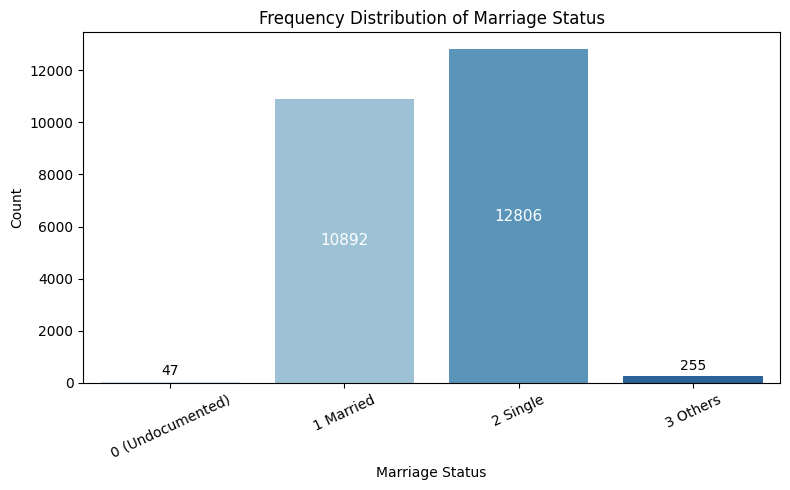

C:\Users\polym\AppData\Local\Temp\ipykernel_28004\426075313.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=marriage_mapped, y=y_train, order=order, palette="Blues")


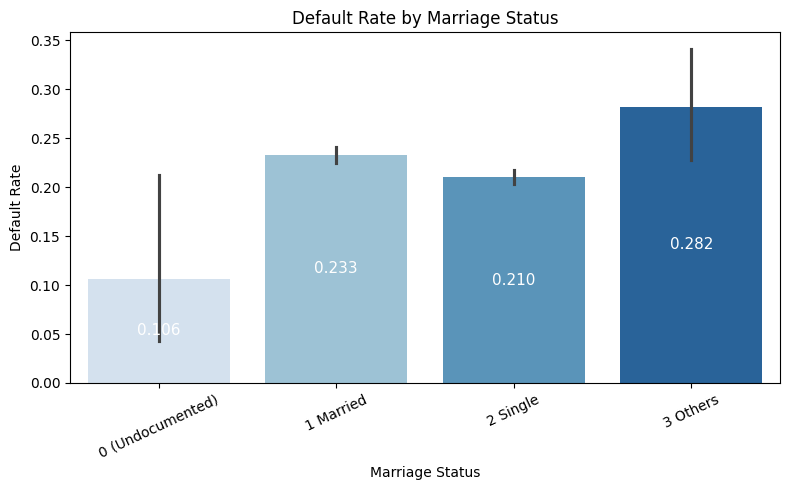

In [24]:
# Map MARRIAGE codes to labels (after inspection)

marriage_labels = {
    0: "0 (Undocumented)",
    1: "1 Married",
    2: "2 Single",
    3: "3 Others"
}

# Create mapped series
marriage_mapped = X_train["MARRIAGE"].map(marriage_labels)

# Define order explicitly to preserve numeric order
order = [
    "0 (Undocumented)",
    "1 Married",
    "2 Single",
    "3 Others"
]

# Distribution Plot
plt.figure(figsize=(8,5))
ax = sns.countplot(x=marriage_mapped, order=order, palette="Blues")

plt.title("Frequency Distribution of Marriage Status")
plt.xlabel("Marriage Status")
plt.ylabel("Count")
plt.xticks(rotation=25)

# Add count labels
max_height = max([p.get_height() for p in ax.patches])

for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width()/2.

    if height < max_height * 0.05:  # very small bars
        ax.annotate(f"{int(height)}",
                    (x, height + max_height*0.01),
                    ha="center", va="bottom",
                    color="black", fontsize=10)
    else:
        ax.annotate(f"{int(height)}",
                    (x, height/2),
                    ha="center", va="center",
                    color="white", fontsize=11)

plt.tight_layout()
plt.show()



# Default Rate by Marriage

plt.figure(figsize=(8,5))
ax = sns.barplot(x=marriage_mapped, y=y_train, order=order, palette="Blues")

plt.title("Default Rate by Marriage Status")
plt.xlabel("Marriage Status")
plt.ylabel("Default Rate")
plt.xticks(rotation=25)

# Add rate labels
for p in ax.patches:
    rate = p.get_height()
    x = p.get_x() + p.get_width()/2.

    if rate < 0.05:
        ax.annotate(f"{rate:.3f}",
                    (x, rate + 0.01),
                    ha="center", va="bottom",
                    color="black", fontsize=10)
    else:
        ax.annotate(f"{rate:.3f}",
                    (x, rate/2),
                    ha="center", va="center",
                    color="white", fontsize=11)

plt.tight_layout()
plt.show()

Among the two dominant groups, Married exhibits a higher default rate (0.233) than Single (0.210). The difference is modest (approximately 2.3 percentage points) but consistent, suggesting that marital status contains some predictive information, although it is unlikely to be a strong standalone predictor.

Category 3 (Others) displays the highest observed default rate (0.282), but the associated uncertainty is larger due to its relatively small sample size (n = 255). Category 0 (Undocumented) shows a lower observed default rate (0.106), accompanied by a very wide confidence interval reflecting substantial sampling uncertainty (n = 47). Given their limited representation, these rare categories should not be interpreted as reliable indicators of default risk in isolation.

From a modelling perspective, MARRIAGE is retained as a categorical predictor and encoded using one-hot encoding during preprocessing. This allows the model to estimate separate effects for each category while preserving the information present in the data. However, estimates for rare categories may be less stable due to their small sample sizes.

These observations describe associations within the training sample rather than causal effects and will be evaluated further during model estimation and validation

### **7.3 Repayment Status Variables (PAY_0, PAY_2-PAY_6):**

We examine the PAY_0 variable to assess whether recent repayment behaviour is associated with subsequent default risk and to verify whether increasing delinquency (being late on a required payment) levels correspond to higher default probability.

PAY_0 distribution (proportions):
PAY_0
-2    0.091583
-1    0.188625
 0    0.490875
 1    0.125000
 2    0.089083
 3    0.010208
 4    0.002417
 5    0.000750
 6    0.000417
 7    0.000375
 8    0.000667
Name: proportion, dtype: float64
Default rate and sample size per PAY_0 category:
 PAY_0  default_rate     n
    -2         0.127  2198
    -1         0.166  4527
     0         0.128 11781
     1         0.344  3000
     2         0.694  2138
     3         0.767   245
     4         0.655    58
     5         0.444    18
     6         0.600    10
     7         0.778     9
     8         0.500    16


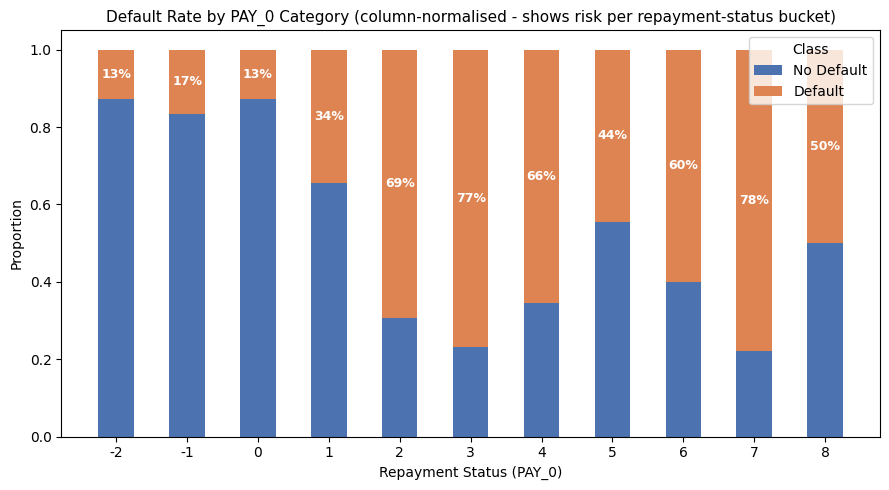

In [25]:


print("PAY_0 distribution (proportions):")
print(X_train["PAY_0"].value_counts(normalize=True).sort_index())

# Summary table: default rate and n per PAY_0 category
pay0_order = sorted(X_train["PAY_0"].unique())
pay0_df = pd.DataFrame({"PAY_0": X_train["PAY_0"].values, "Default": y_train.values})

cond = (
    pay0_df.groupby("PAY_0")["Default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n"})
    .loc[pay0_order]
    .reset_index()
)
cond["no_default_rate"] = 1 - cond["default_rate"]

print("Default rate and sample size per PAY_0 category:")
print(    cond[["PAY_0", "default_rate", "n"]] .assign(default_rate=cond["default_rate"].round(3)).to_string(index=False))

# Default rate per PAY_0 category (column-normalised stacked bar)
palette = ["#4C72B0", "#DD8452"]
x_pos = np.arange(len(cond))
w = 0.5

plt.figure(figsize=(9, 5))
plt.bar(x_pos, cond["no_default_rate"], width=w, color=palette[0], label="No Default")
plt.bar(x_pos, cond["default_rate"], width=w, bottom=cond["no_default_rate"],
        color=palette[1], label="Default")

for xi, row in zip(x_pos, cond.itertuples()):
    if row.default_rate >= 0.05:
        plt.text(xi, row.no_default_rate + row.default_rate / 2,
                 f"{row.default_rate:.0%}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")

plt.xticks(x_pos, cond["PAY_0"])
plt.xlabel("Repayment Status (PAY_0)")
plt.ylabel("Proportion")
plt.title("Default Rate by PAY_0 Category (column-normalised - shows risk per repayment-status bucket)",
          fontsize=11)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

The distribution of PAY_0 shows that most clients fall within low or no delinquency states: status 0 alone accounts for 49% of the training sample, while severe delay categories (4–8) are rare (n < 60 each). Clients with no consumption or pay-ahead behaviour (status -2) and those who paid duly (status -1) show default rates of only 13–17%, and status 0 (revolving credit, minimum payment made) is similarly low at 13%. The risk gradient sharpens dramatically from status 1 onwards: a single month's delay corresponds to a 34% default rate, rising to 69% for two months (status 2) and 77% for three months (status 3). Severe delinquency categories (status 4–8) show volatile default rates between 44–78%, though these estimates carry greater uncertainty due to very small sample sizes. Overall, PAY_0 displays a clear monotonic risk gradient and is likely one of the most informative features in the model.

### **7.4 Remaining Repayment Status Variables (PAY_2–PAY_6):**

We examine PAY_2 - PAY_6 to check whether higher repayment delay in earlier months is also associated with higher default risk, and whether this pattern is consistent over time.

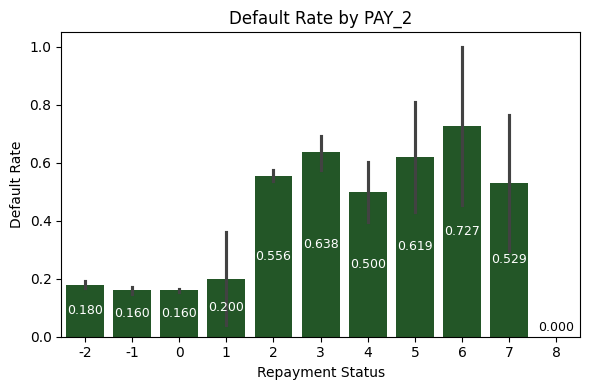

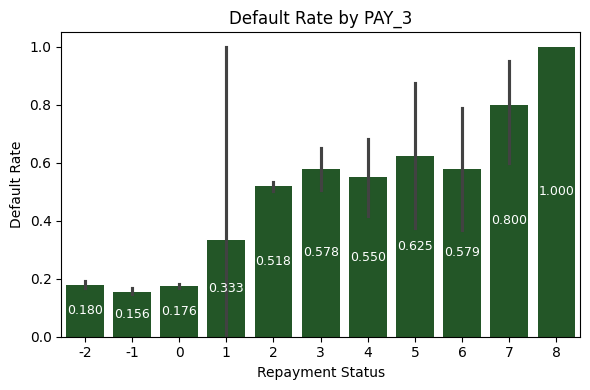

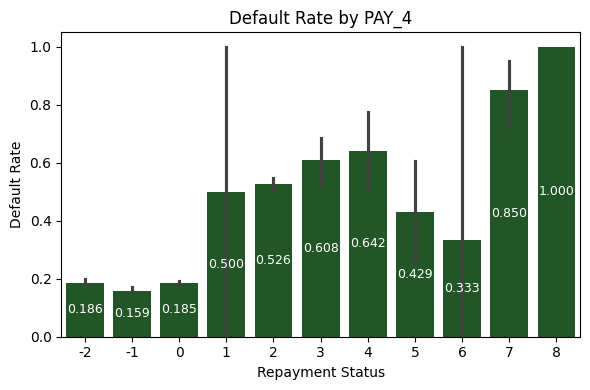

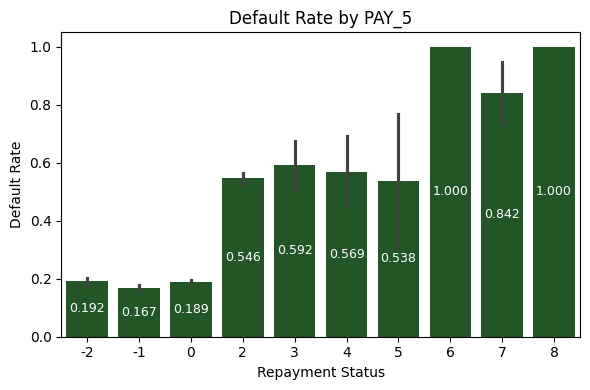

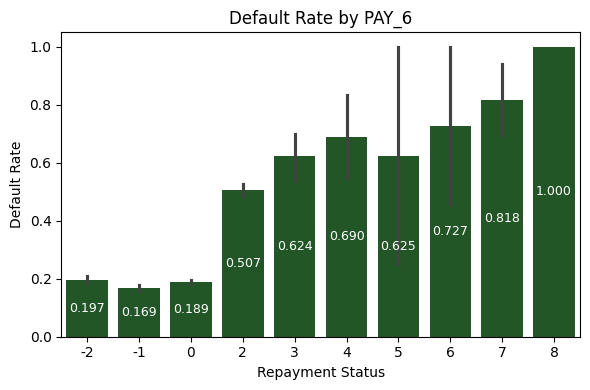

In [26]:
repay_cols = ["PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

dark_green = "#1B5E20"   # deep green

for col in repay_cols:
    plt.figure(figsize=(6,4))
    
    ax = sns.barplot(
        x=X_train[col],
        y=y_train,
        color=dark_green
    )

    plt.title(f"Default Rate by {col}")
    plt.xlabel("Repayment Status")
    plt.ylabel("Default Rate")

    # Add default rate labels
    for p in ax.patches:
        rate = p.get_height()
        x = p.get_x() + p.get_width() / 2

        if rate < 0.05:
            ax.annotate(
                f"{rate:.3f}",
                (x, rate + 0.01),
                ha="center",
                va="bottom",
                fontsize=9
            )
        else:
            ax.annotate(
                f"{rate:.3f}",
                (x, rate / 2),
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

In [27]:
# Default rate summary tables for PAY_2 – PAY_6
repay_cols = ["PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in repay_cols:
    col_order = sorted(X_train[col].unique())
    summary_df = pd.DataFrame({"status": X_train[col].values, "Default": y_train.values})

    tbl = (
        summary_df.groupby("status")["Default"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "default_rate", "count": "n"})
        .loc[col_order]
        .reset_index()
        .rename(columns={"status": col})
        .assign(default_rate=lambda d: d["default_rate"].round(3))
    )

    print(f"\n{col}: default rate and sample size per repayment-status category:")
    print(tbl.to_string(index=False))


PAY_2: default rate and sample size per repayment-status category:
 PAY_2  default_rate     n
    -2         0.180  3030
    -1         0.160  4845
     0         0.160 12573
     1         0.200    25
     2         0.556  3145
     3         0.638   254
     4         0.500    78
     5         0.619    21
     6         0.727    11
     7         0.529    17
     8         0.000     1

PAY_3: default rate and sample size per repayment-status category:
 PAY_3  default_rate     n
    -2         0.180  3270
    -1         0.156  4733
     0         0.176 12636
     1         0.333     3
     2         0.518  3049
     3         0.578   192
     4         0.550    60
     5         0.625    16
     6         0.579    19
     7         0.800    20
     8         1.000     2

PAY_4: default rate and sample size per repayment-status category:
 PAY_4  default_rate     n
    -2         0.186  3477
    -1         0.159  4531
     0         0.185 13180
     1         0.500     2
     2       

Across PAY₂–PAY₆, a similar risk gradient to that observed in PAY₀ is visible. Low delinquency categories (−2, −1, 0) consistently exhibit default rates of roughly 16–20%, based on very large sample sizes, keeping them close to or slightly below the overall default rate of 22.1%.

Default risk increases sharply beginning at status 2, where observed default rates rise to around 51–56% across months. For higher delinquency levels (statuses 3–5), default rates remain elevated, generally in the mid-50% to low-60% range, though the pattern is not perfectly monotonic — likely reflecting sampling noise in these smaller groups, as seen for example in PAY₂ = 4 (50.0%) and PAY₄ = 5 (42.9%).

At extreme delinquency levels (6–8), default rates become highly volatile and in some cases reach or approach 100%, but these estimates are based on very small samples and should therefore be interpreted cautiously. The widening confidence intervals in these categories indicate substantial statistical uncertainty.

Another notable pattern is the rarity of status 1 in PAY₂–PAY₆. It appears only 25 times in PAY₂, 3 times in PAY₃, 2 times in PAY₄, and is absent in PAY₅ and PAY₆. This contrasts sharply with PAY₀, where one-month delays are much more common.

Overall, repayment status across all months shows a strong and consistent association with default risk, with the most pronounced increase occurring between status 0 and status 2.

### **7.5 Correlation Among Financial Variables:**

We examine correlations among continuous financial variables to assess the degree of multicollinearity, particularly across monthly bill and payment amounts, as highly correlated features may affect model stability and especially interpretation.

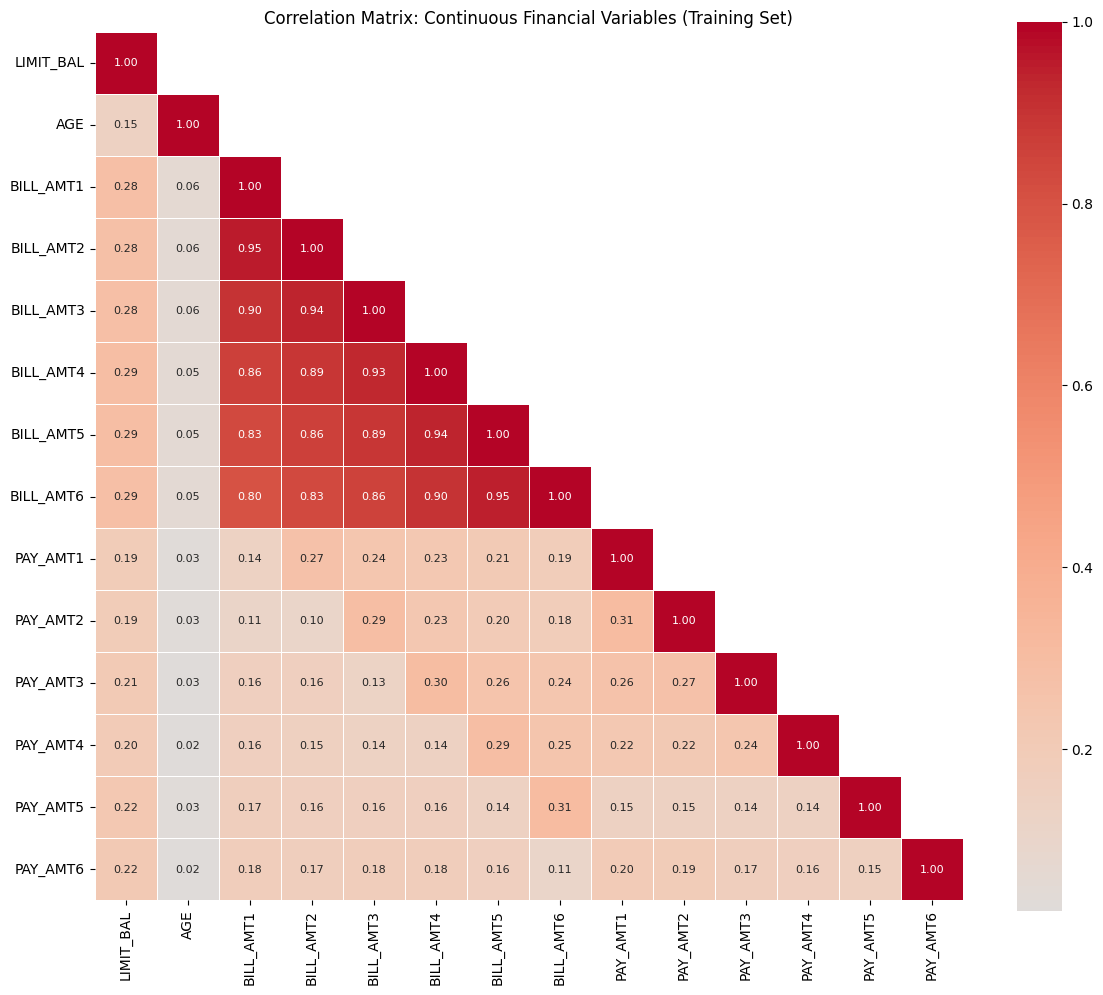

In [28]:
# Continuous financial variables
amount_cols = (
    ["LIMIT_BAL", "AGE"] +
    [f"BILL_AMT{i}" for i in range(1,7)] +
    [f"PAY_AMT{i}" for i in range(1,7)]
)

# Correlation matrix (lower triangle only)
corr_matrix = X_train[amount_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    square=True,
)
plt.title("Correlation Matrix: Continuous Financial Variables (Training Set)", fontsize=12
)
plt.tight_layout()
plt.show()

The correlation matrix reveals a strong block of high positive correlations among BILL_AMT1–BILL_AMT6, ranging from 0.80 to 0.95. Adjacent months exhibit the strongest correlations (e.g., BILL_AMT1–BILL_AMT2 = 0.95), while correlations decrease slightly as the temporal gap increases (e.g., BILL_AMT1–BILL_AMT6 = 0.80). This indicates that outstanding balances are highly persistent across months, suggesting that balances tend to carry over rather than fluctuating independently each month.

In contrast, PAY_AMT1–PAY_AMT6 display much weaker inter-month correlations (0.14–0.31), indicating that payment behaviour varies more across months than balance levels.

Cross-correlations between BILL_AMT and PAY_AMT variables are also relatively weak (0.10–0.31), suggesting only a modest association between balance levels and payment amounts.

LIMIT_BAL shows weak positive correlations with bill amounts (0.28–0.29) and payment amounts (0.19–0.22), indicating that clients with higher credit limits tend to have somewhat larger balances and payments, although the relationship is not strong. AGE shows near-zero correlations with the financial variables (0.02–0.06), suggesting little linear association with these measures.

The BILL_AMT variables exhibit very strong intercorrelations (r ≈ 0.9), indicating that outstanding balances tend to persist across months. This suggests potential multicollinearity if all variables are included in linear models. During modelling, approaches such as regularisation or selecting a representative subset of variables (e.g., BILL_AMT1) may therefore be explored, while tree-based models are expected to be less sensitive to such correlations.

## EDA Summary: Key Findings and Modelling Implications

The table below consolidates the principal findings from the exploratory analysis. Each row covers a variable or variable group, the observed pattern, and the direct consequence for modelling and preprocessing.




| Variable / Group | Key Finding | Modelling Implication |
|---|---|---|
| **Target (`default`)** | 78% No Default / 22% Default, moderate class imbalance, preserved by stratified split in both train and test sets. | Accuracy is misleading. Evaluated with ROC-AUC and PR-AUC. SMOTE and random undersampling compared; undersampling carried forward. Threshold optimised post-training. |
| **`LIMIT_BAL`** | Clear separation by class: median NT$150,000 for non-defaulters vs NT$90,000 for defaulters (~67% gap). Right-skewed with long upper tail. | Retained. StandardScaler applied. UTIL_RATE engineered (BILL_AMT1 / LIMIT_BAL) to capture credit utilisation. |
| **`AGE`** | Non-monotonic pattern: 30–39 lowest (20.2%), rising to 27.8% for 60+. The 60+ bin contains only 263 observations. | Retained as-is. StandardScaler applied. No binning implemented — weak signal insufficient to justify added complexity. |
| **`SEX`** | Males default at 24.4% vs females 20.6% (~4 pp gap). Both groups well represented. | OneHotEncoder with drop='first' applied. Retained but expected low importance in tree-based models. |
| **`EDUCATION`** | Partial monotonic pattern: Graduate (19.3%) < University (23.8%) < High School (25.0%). Codes 0, 5, 6 undocumented (n=12, 235, 42). | OneHotEncoder with drop='first' applied. Undocumented codes 0, 5, 6 remapped to category 4 (Others) during preprocessing. |
| **`MARRIAGE`** | Married (23.3%) vs Single (21.0%), ~2 pp difference. Code 0 undocumented (n=47). | OneHotEncoder with drop='first' applied. Code 0 remapped to category 3 (Others) during preprocessing. |
| **`PAY_0`** | Strongest predictor. Default rate low at status −2 (13%), −1 (17%), 0 (12.8%); rises steeply to 34% at status 1, 69% at status 2, 77% at status 3. | Treated as ordinal. StandardScaler applied. Retained as-is — non-linear step-change captured natively by tree-based models. |
| **`PAY_2`–`PAY_6`** | Same risk gradient replicated across all five months. Default rates ≥ 50% for delay status 2+ in every month. | Treated as ordinal. StandardScaler applied. AVG_PAY_STATUS and MAX_DLQ engineered as summary features across the six PAY columns. |
| **`BILL_AMT1`–`BILL_AMT6`** | Extremely high inter-month correlations (r = 0.80–0.95), indicating persistent debt carryover. All six heavily right-skewed. | StandardScaler applied. BILL_TREND (BILL_AMT1 − BILL_AMT6) engineered to capture billing direction. TOTAL_BILL engineered as an aggregate. All six retained for tree-based models. |
| **`PAY_AMT1`–`PAY_AMT6`** | Moderate inter-month correlations (r = 0.14–0.31). Severely right-skewed, compressed near zero. | StandardScaler applied. TOTAL_PAY and PAY_RATIO (TOTAL_PAY / (TOTAL_BILL + 1)) engineered as summary features. All six retained. |



In [29]:


# Save train/test splits to data/processed/ (one level above notebooks/)
output_dir = os.path.join(os.path.dirname(os.getcwd()), "data", "processed")
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False)

print(f"Saved to: {output_dir}")
print(f"  X_train.csv  -- {X_train.shape}")
print(f"  X_test.csv   -- {X_test.shape}")
print(f"  y_train.csv  -- {y_train.shape}")
print(f"  y_test.csv   -- {y_test.shape}")

Saved to: c:\Users\polym\Desktop\Term_2\Predictive\Assignment\Code\PA\data\processed
  X_train.csv  -- (24000, 23)
  X_test.csv   -- (6000, 23)
  y_train.csv  -- (24000,)
  y_test.csv   -- (6000,)
